In [5]:
# Step 1: Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


In [6]:
# Step 2: Load the dataset
file_path = "unified mentor projects/googleplaystore (1).csv"

df = pd.read_csv(file_path)

# Keep a copy
raw_df = df.copy()

# Look at first few rows
print(df.head())


                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art & Design;Pretend 

In [7]:
# Step 3: Clean and transform important columns

def parse_installs(x):
    if pd.isna(x): return np.nan
    x = str(x).replace("+","").replace(",","")
    return int(x) if x.isdigit() else np.nan

def parse_price(x):
    if pd.isna(x): return 0.0
    return float(str(x).replace("$","")) if str(x).replace("$","").replace(".","").isdigit() else np.nan

def parse_size(x):
    if pd.isna(x): return np.nan
    s = str(x)
    if "Varies" in s: return np.nan
    if s.endswith("M"): return float(s[:-1])
    if s.endswith("k") or s.endswith("K"): return float(s[:-1]) / 1024
    return np.nan

df["installs_clean"] = df["Installs"].apply(parse_installs)
df["price_clean"]    = df["Price"].apply(parse_price)
df["size_mb"]        = df["Size"].apply(parse_size)
df["reviews_num"]    = pd.to_numeric(df["Reviews"], errors="coerce")
df["rating_num"]     = pd.to_numeric(df["Rating"], errors="coerce")

df["size_mb"].fillna(df["size_mb"].median(), inplace=True)
df["rating_num"].fillna(df["rating_num"].median(), inplace=True)


In [8]:
# Step 4: Create new useful features
df["log_reviews"]  = np.log1p(df["reviews_num"])
df["log_installs"] = np.log1p(df["installs_clean"])
df["is_paid"]      = (df["Type"] == "Paid").astype(int)

df["last_updated_dt"] = pd.to_datetime(df["Last Updated"], errors="coerce")
max_date = df["last_updated_dt"].max()
df["days_since_update"] = (max_date - df["last_updated_dt"]).dt.days


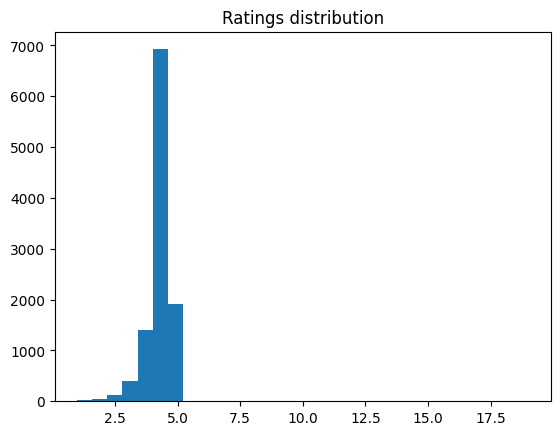

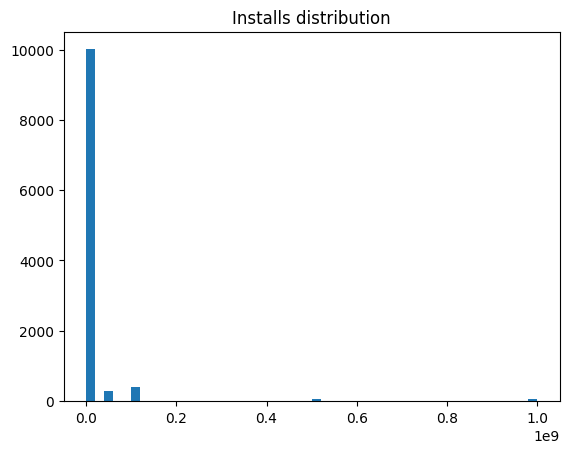

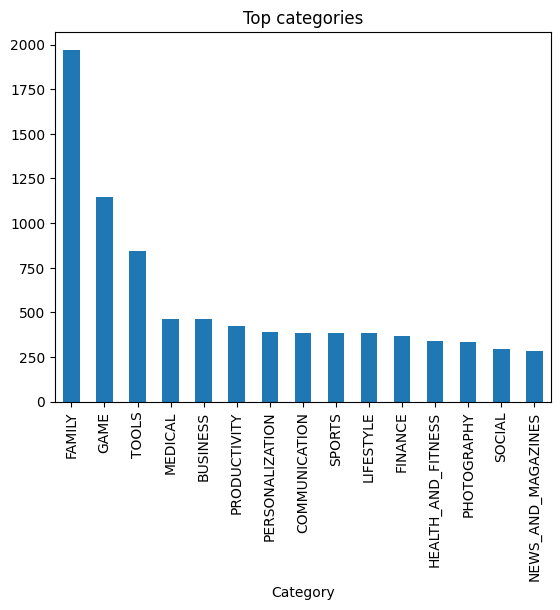

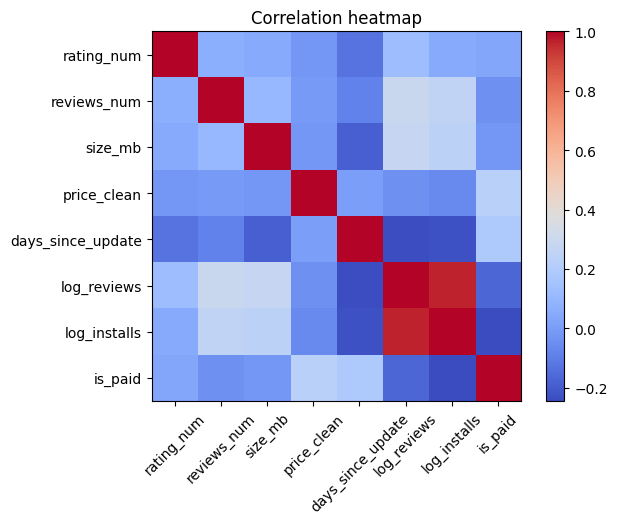

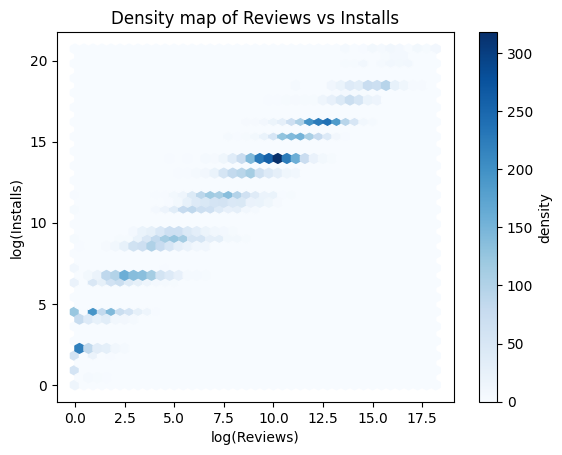

In [9]:
# Step 5: Visualizations (maps)

# 1. Ratings distribution
plt.hist(df["rating_num"], bins=30)
plt.title("Ratings distribution")
plt.show()

# 2. Installs distribution
plt.hist(df["installs_clean"].dropna(), bins=50)
plt.title("Installs distribution")
plt.show()

# 3. Top categories
df["Category"].value_counts().head(15).plot(kind="bar")
plt.title("Top categories")
plt.show()

# 4. Correlation heatmap
num_cols = ["rating_num","reviews_num","size_mb","price_clean","days_since_update","log_reviews","log_installs","is_paid"]
corr = df[num_cols].corr()
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation heatmap")
plt.show()

# 5. Hexbin density map: Reviews vs Installs
plt.hexbin(df["log_reviews"], df["log_installs"], gridsize=40, cmap="Blues")
plt.colorbar(label="density")
plt.xlabel("log(Reviews)")
plt.ylabel("log(Installs)")
plt.title("Density map of Reviews vs Installs")
plt.show()


In [10]:
# Step 6: Regression models
features = ["log_reviews","log_installs","size_mb","price_clean","days_since_update","is_paid","Category"]
target   = "rating_num"

model_df = df[features + [target]].dropna()
X = model_df[features]
y = model_df[target]

ct = ColumnTransformer([("ohe", OneHotEncoder(handle_unknown="ignore"), ["Category"])], remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Linear Regression
lr = Pipeline([("prep", ct), ("model", LinearRegression())])
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test,y_pred))
print("MAE:", mean_absolute_error(y_test,y_pred))

# Random Forest
rf = Pipeline([("prep", ct), ("model", RandomForestRegressor(n_estimators=200, random_state=42))])
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RandomForest R2:", r2_score(y_test,y_pred_rf))
print("MAE:", mean_absolute_error(y_test,y_pred_rf))


Linear Regression R2: 0.11341434941406137
MAE: 0.29645553926903456
RandomForest R2: 0.15040996261513695
MAE: 0.27524700184501866


In [11]:
# Step 7: Classification: High Installs (≥ 1M)
df["high_installs"] = (df["installs_clean"] >= 1_000_000).astype(int)

features_clf = ["log_reviews","size_mb","price_clean","days_since_update","is_paid","Category"]
target_clf   = "high_installs"

clf_df = df[features_clf + [target_clf]].dropna()
Xc = clf_df[features_clf]
yc = clf_df[target_clf]

ct_c = ColumnTransformer([("ohe", OneHotEncoder(handle_unknown="ignore"), ["Category"])], remainder="passthrough")

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc,yc,test_size=0.2,random_state=42,stratify=yc)

# Logistic Regression
logreg = Pipeline([("prep", ct_c), ("model", LogisticRegression(max_iter=200))])
logreg.fit(Xc_train, yc_train)
print("LogReg ACC:", accuracy_score(yc_test, logreg.predict(Xc_test)))
print("LogReg AUC:", roc_auc_score(yc_test, logreg.predict_proba(Xc_test)[:,1]))

# Random Forest Classifier
rf_clf = Pipeline([("prep", ct_c), ("model", RandomForestClassifier(n_estimators=200,random_state=42))])
rf_clf.fit(Xc_train,yc_train)
print("RF ACC:", accuracy_score(yc_test, rf_clf.predict(Xc_test)))
print("RF AUC:", roc_auc_score(yc_test, rf_clf.predict_proba(Xc_test)[:,1]))


LogReg ACC: 0.9589483394833949
LogReg AUC: 0.992349142871249
RF ACC: 0.959409594095941
RF AUC: 0.9907683654073346


In [12]:
# Step 8: Store cleaned data into SQLite
conn = sqlite3.connect("google_play.db")
df_sql = df[["App","Category","rating_num","reviews_num","size_mb","installs_clean","Type","price_clean","Content Rating","Genres","last_updated_dt","days_since_update","log_reviews","log_installs","is_paid","high_installs"]]
df_sql.to_sql("apps_cleaned", conn, if_exists="replace", index=False)

# Example SQL query: Top categories by avg rating
query = """
SELECT Category, COUNT(*) as n, ROUND(AVG(rating_num),2) as avg_rating
FROM apps_cleaned
GROUP BY Category
HAVING n > 20
ORDER BY avg_rating DESC
LIMIT 10;
"""
print(pd.read_sql_query(query, conn))
conn.close()


              Category     n  avg_rating
0               EVENTS    64        4.40
1            EDUCATION   156        4.39
2       ART_AND_DESIGN    65        4.36
3  BOOKS_AND_REFERENCE   231        4.34
4      PERSONALIZATION   392        4.33
5            PARENTING    60        4.30
6                 GAME  1144        4.29
7   HEALTH_AND_FITNESS   341        4.28
8               BEAUTY    53        4.28
9               SOCIAL   295        4.26


In [25]:
import seaborn as sns
import numpy as np
import pandas as pd

# Load data
df = pd.read_csv("unified mentor projects/googleplaystore (1).csv")

# --- CLEAN SIZE ---
def parse_size(x):
    if isinstance(x, str):
        x = x.strip()
        if x.endswith("M"):
            return float(x.replace("M","")) * 1_000_000
        elif x.endswith("k") or x.endswith("K"):
            return float(x.replace("k","").replace("K","")) * 1_000
        elif x.lower() == "varies with device":
            return np.nan
    try:
        return float(x)
    except:
        return np.nan

df["Size_clean"] = df["Size"].apply(parse_size)
df["Size_clean"].fillna(df["Size_clean"].median(), inplace=True)

# --- CLEAN INSTALLS ---
df["Installs_clean"] = (
    df["Installs"].astype(str)
    .str.replace("+","", regex=False)
    .str.replace(",","", regex=False)
    .replace("Free", np.nan)   # handle bad rows
    .astype(float)
)

# --- CLEAN PRICE ---
df["Price_clean"] = (
    df["Price"].astype(str)
    .str.replace("$","", regex=False)
    .replace("Everyone", np.nan)   # handle wrong entries
    .astype(float)
)

# --- CLEAN REVIEWS ---
df["Reviews_clean"] = pd.to_numeric(df["Reviews"], errors="coerce")

# --- ADD FREE/PAID FLAG ---
df["App_Type"] = df["Type"].apply(lambda x: "Paid" if str(x).lower()=="paid" else "Free")



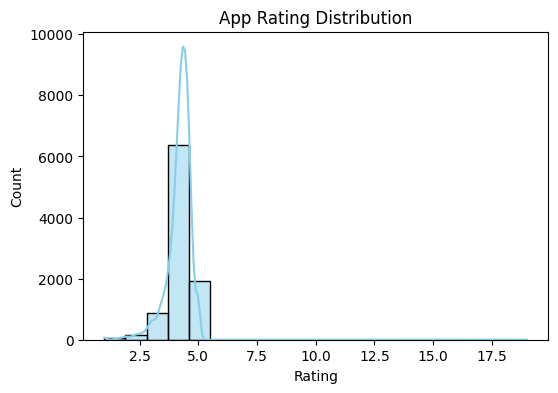

In [26]:
# 1. Rating distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Rating"], bins=20, kde=True, color="skyblue")
plt.title("App Rating Distribution")
plt.show()

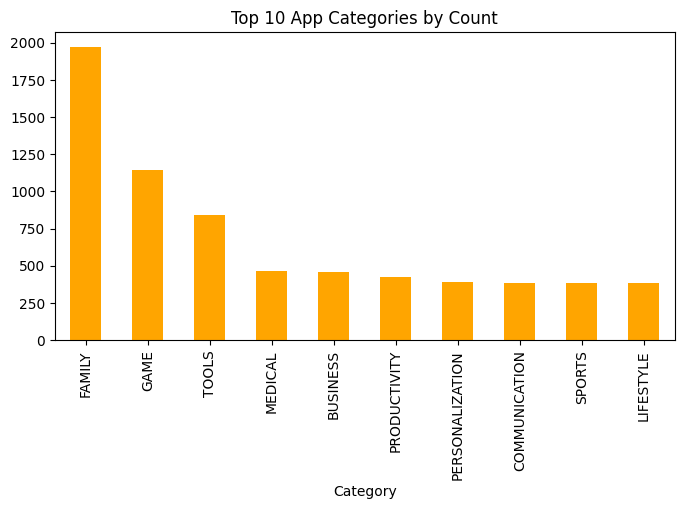

In [27]:
# 2. Top categories by app count
plt.figure(figsize=(8,4))
df["Category"].value_counts().head(10).plot(kind="bar", color="orange")
plt.title("Top 10 App Categories by Count")
plt.show()

In [28]:
# Clean Installs column
df["Installs_clean"] = (
    df["Installs"].astype(str)
    .str.replace("+","", regex=False)
    .str.replace(",","", regex=False)
    .replace("Free", np.nan)   # Some rows have weird "Free"
    .astype(float)
)

# Clean Price column
df["Price_clean"] = (
    df["Price"].astype(str)
    .str.replace("$","", regex=False)
    .replace("Everyone", np.nan)   # in case of wrong values
    .astype(float)
)

# Add Free/Paid flag (so no `is_paid` error)
df["App_Type"] = df["Type"].apply(lambda x: "Paid" if str(x).lower()=="paid" else "Free")


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns


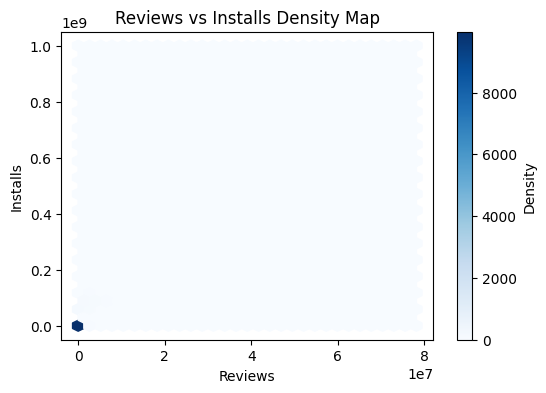

In [30]:
plt.figure(figsize=(6,4))
plt.hexbin(df["Reviews_clean"], df["Installs_clean"], gridsize=30, cmap="Blues")
plt.colorbar(label="Density")
plt.xlabel("Reviews")
plt.ylabel("Installs")
plt.title("Reviews vs Installs Density Map")
plt.show()

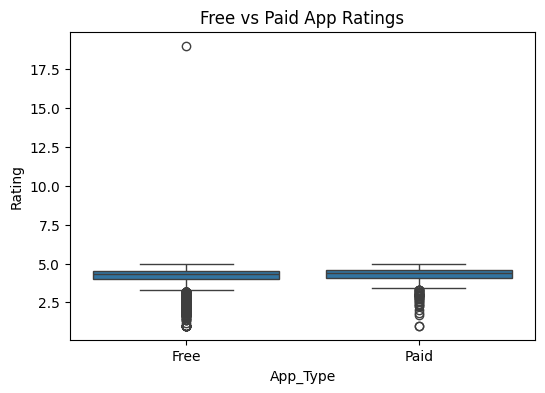

In [31]:
# 4. Free vs Paid Rating comparison
plt.figure(figsize=(6,4))
sns.boxplot(x="App_Type", y="Rating", data=df)
plt.title("Free vs Paid App Ratings")
plt.show()

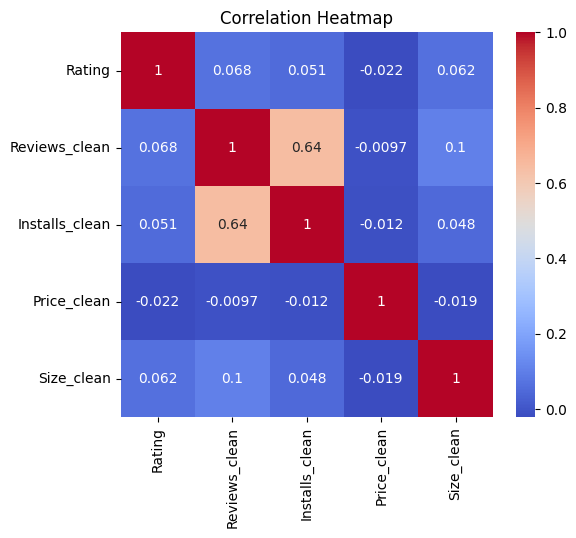

In [32]:
# 5. Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    df[["Rating","Reviews_clean","Installs_clean","Price_clean","Size_clean"]].corr(),
    annot=True, cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [33]:
import sqlite3

# Connect to SQLite DB (or create if not exists)
conn = sqlite3.connect("googleplaystore.db")
cursor = conn.cursor()

# Save cleaned dataframe to SQL
df.to_sql("apps", conn, if_exists="replace", index=False)


10841

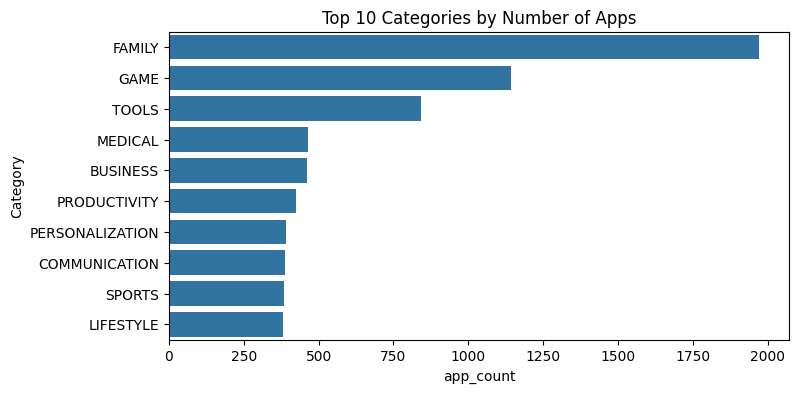

In [34]:
query = """
SELECT Category, COUNT(*) as app_count
FROM apps
GROUP BY Category
ORDER BY app_count DESC
LIMIT 10;
"""
top_categories = pd.read_sql(query, conn)

plt.figure(figsize=(8,4))
sns.barplot(x="app_count", y="Category", data=top_categories)
plt.title("Top 10 Categories by Number of Apps")
plt.show()


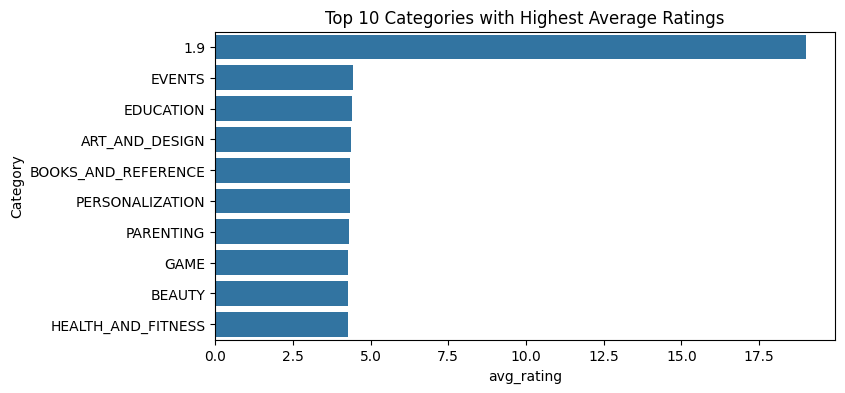

In [35]:
query = """
SELECT Category, AVG(Rating) as avg_rating
FROM apps
WHERE Rating IS NOT NULL
GROUP BY Category
ORDER BY avg_rating DESC
LIMIT 10;
"""
avg_rating = pd.read_sql(query, conn)

plt.figure(figsize=(8,4))
sns.barplot(x="avg_rating", y="Category", data=avg_rating)
plt.title("Top 10 Categories with Highest Average Ratings")
plt.show()


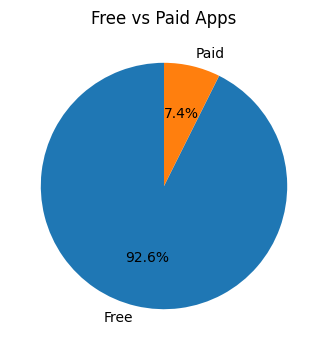

In [36]:
query = """
SELECT App_Type, COUNT(*) as total
FROM apps
GROUP BY App_Type;
"""
free_paid = pd.read_sql(query, conn)

plt.figure(figsize=(5,4))
plt.pie(free_paid["total"], labels=free_paid["App_Type"], autopct="%1.1f%%", startangle=90)
plt.title("Free vs Paid Apps")
plt.show()


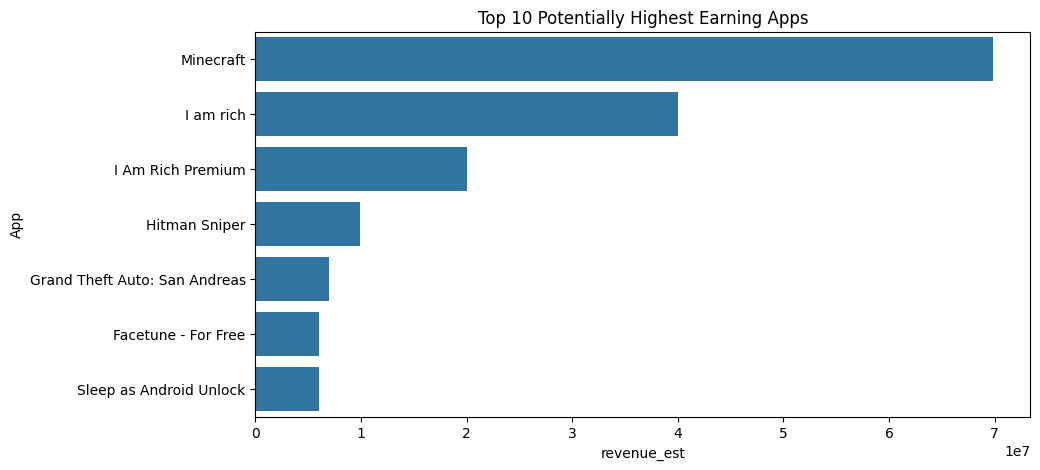

In [37]:
query = """
SELECT App, (Price_clean * Installs_clean) as revenue_est
FROM apps
WHERE Price_clean > 0
ORDER BY revenue_est DESC
LIMIT 10;
"""
top_earning = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(x="revenue_est", y="App", data=top_earning)
plt.title("Top 10 Potentially Highest Earning Apps")
plt.show()


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Copy dataframe
ml_df = df.copy()

# Handle categorical features (Category, Content Rating, Genres)
label_cols = ["Category", "Content Rating", "Genres"]
for col in label_cols:
    ml_df[col] = LabelEncoder().fit_transform(ml_df[col].astype(str))

# Define features and target
features = ["Reviews_clean", "Installs_clean", "Price_clean", "Size_clean", "Category", "Content Rating", "Genres"]
target = "Rating"

X = ml_df[features]
y = ml_df[target]

# Drop rows with missing target
X = X[y.notnull()]
y = y[y.notnull()]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Regression Results:
MSE: 0.21579400388286768
R²: 0.12472089955603494


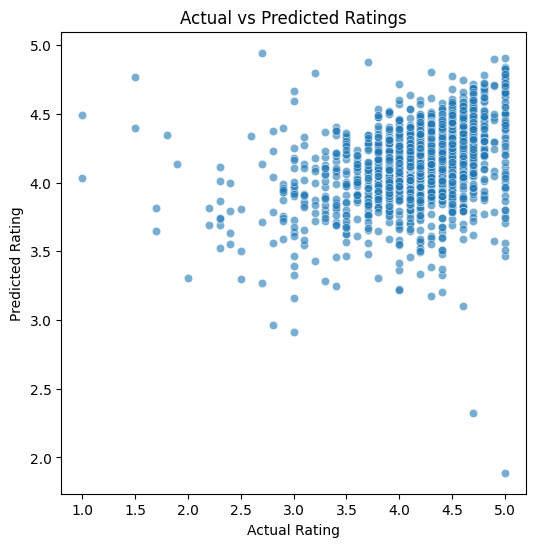

In [39]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)

print("Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Plot predicted vs actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.56      0.62       697
           1       0.81      0.88      0.84      1472

    accuracy                           0.78      2169
   macro avg       0.75      0.72      0.73      2169
weighted avg       0.77      0.78      0.77      2169



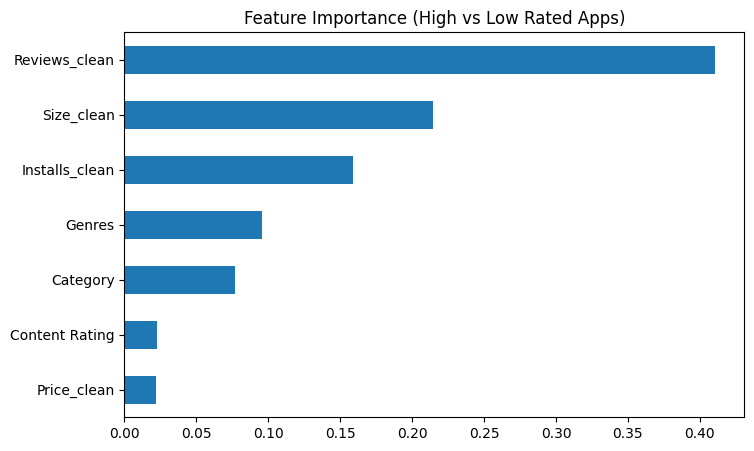

In [40]:
ml_df["High_Rated"] = (ml_df["Rating"] >= 4.0).astype(int)

X_cls = ml_df[features]
y_cls = ml_df["High_Rated"]

X_cls = X_cls[y_cls.notnull()]
y_cls = y_cls[y_cls.notnull()]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

rf_cls = RandomForestClassifier(n_estimators=200, random_state=42)
rf_cls.fit(Xc_train, yc_train)

yc_pred = rf_cls.predict(Xc_test)

print("Classification Report:")
print(classification_report(yc_test, yc_pred))

# Feature importance
feat_importances = pd.Series(rf_cls.feature_importances_, index=features)
feat_importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance (High vs Low Rated Apps)")
plt.show()
